## Movie Review Sentiment Classifier

---

### Overview
This notebook covers the full NLP pipeline from raw text to transformer-based classification, applied to the IMDB movie review dataset.

**Concepts covered:**
- Text preprocessing: tokenization, stopword removal, stemming, lemmatization
- Feature extraction: Bag-of-Words, TF-IDF
- Word embeddings: Word2Vec (trained from scratch), GloVe (pretrained)
- Classical ML classifiers: Logistic Regression, Naive Bayes, LinearSVC
- Transformers: BERT architecture overview, DistilBERT fine-tuning with Hugging Face
- Full model comparison across all approaches

**Dataset:** `IMDB_Dataset.csv` — 50,000 labeled movie reviews (positive / negative), balanced.

---

### Note on BERT Fine-tuning
The DistilBERT section is computationally intensive. Running with a GPU (Google Colab or local CUDA) is recommended for full training. A small subset (2,000 samples) is used by default so the cell can also run on CPU in reasonable time.

## Step 0 — Install Dependencies

In [ ]:
# Run once to install all required packages
!pip install transformers torch scikit-learn nltk gensim matplotlib seaborn wordcloud tqdm

## Step 1 — Imports

In [ ]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

from gensim.models import Word2Vec
from wordcloud import WordCloud
from sklearn.manifold import TSNE

for pkg in ['punkt', 'stopwords', 'wordnet', 'punkt_tab', 'averaged_perceptron_tagger']:
    nltk.download(pkg, quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

print("Imports complete.")

Imports complete.


---

## Step 2 — Load Dataset

We load `IMDB_Dataset.csv` and sample **1,000 positive + 1,000 negative** reviews (2,000 total) for a fast, balanced experiment. We then apply an 80/20 stratified split → **1,600 train / 400 test**.

In [ ]:
df = pd.read_csv('IMDB_Dataset.csv')

# Create numeric label: 1 = positive, 0 = negative
df['label'] = (df['sentiment'] == 'positive').astype(int)

# Sample 1,000 positive and 1,000 negative reviews
df = pd.concat([
    df[df['label'] == 1].sample(1000, random_state=RANDOM_STATE),
    df[df['label'] == 0].sample(1000, random_state=RANDOM_STATE),
]).reset_index(drop=True)

print(f"Working dataset: {df.shape}")
print(f"Label distribution: {df['label'].value_counts().to_dict()}")

# 80/20 stratified split  →  1,600 train / 400 test
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE, stratify=df['label']
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)} rows | Test: {len(test_df)} rows")
print(f"Train label balance: {train_df['label'].value_counts().to_dict()}")
print(f"Test  label balance: {test_df['label'].value_counts().to_dict()}")

Working dataset: (2000, 3)
Label distribution: {1: 1000, 0: 1000}

Train: 1600 rows | Test: 400 rows
Train label balance: {1: 800, 0: 800}
Test  label balance: {0: 200, 1: 200}


In [ ]:
train_df[['review', 'sentiment']].head(3)

,review,sentiment
0,"Okay, so I love silly movies. If you enjoy sil...",positive
1,Without doubt the best of the novels of John L...,positive
2,"The comment by ""eliz7212-1"" hits the proverbia...",negative


In [ ]:
print("POSITIVE REVIEW:")
print(train_df[train_df['label'] == 1]['review'].iloc[0][:500])
print("\n" + "-" * 60)
print("\nNEGATIVE REVIEW:")
print(train_df[train_df['label'] == 0]['review'].iloc[0][:500])

POSITIVE REVIEW:
Okay, so I love silly movies. If you enjoy silly sci-fi movies, over the top movies, or if you are a fan of Mr. Bruce Campbell, i would go see this movie. This movie is all that i wanted it to be. Being a fan of over the top movies, this fit the bill. Every time i thought to myself "this movie would be the sillest, best movie ever if *blank* would happen...." then just as i thought it, *blank* would happen. It's a wonderful silly 'b'-movie. If you are a fan of Campbell i'd say 'see it', bring yo

------------------------------------------------------------

NEGATIVE REVIEW:
The comment by "eliz7212-1" hits the proverbial "nail on the head" for this turkey of a program. But it is a hoot to watch William Shatner "cavort" and "dance" (yes, the " " marks on the word dance are necessary for what Bill does). This show would be a great skit on SNL or MAD TV - and it does rate a few stars for one viewing, or so, to see Shatner, who seems to have taken "camp" to new heights - w

---

## Step 3 — Exploratory Data Analysis

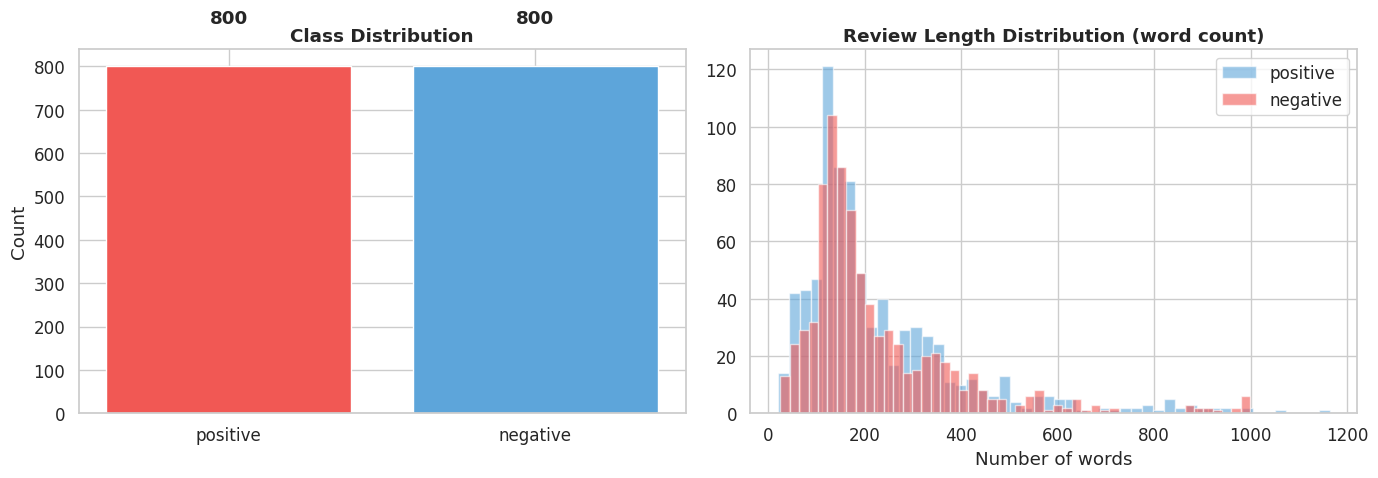

Average review length: 229 words
Median review length:  169 words


In [ ]:
train_df['review_length'] = train_df['review'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = train_df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#F15854', '#5DA5DA'], edgecolor='white')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

for sentiment, color in [('positive', '#5DA5DA'), ('negative', '#F15854')]:
    subset = train_df[train_df['sentiment'] == sentiment]['review_length']
    axes[1].hist(subset, bins=50, alpha=0.6, label=sentiment, color=color)
axes[1].set_title('Review Length Distribution (word count)', fontweight='bold')
axes[1].set_xlabel('Number of words')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Average review length: {train_df['review_length'].mean():.0f} words")
print(f"Median review length:  {train_df['review_length'].median():.0f} words")

---

## Step 4 — Text Preprocessing

Raw text cannot be fed directly into machine learning models. We need to:
1. **Lowercase** — "Movie" and "movie" should be the same token
2. **Remove HTML tags** — IMDB reviews often contain `<br />` tags
3. **Remove punctuation and special characters**
4. **Tokenize** — split text into individual words
5. **Remove stopwords** — common words like "the", "is", "a" carry no sentiment signal
6. **Stem or Lemmatize** — reduce words to their root form ("running" → "run")

### Stemming vs Lemmatization

| Technique | Input | Output | Notes |
|---|---|---|---|
| Stemming (Porter) | "running" | "run" | Fast, crude — may produce non-words |
| Lemmatization | "running" | "run" | Slower, linguistically correct |
| Stemming | "studies" | "studi" | Non-word result |
| Lemmatization | "studies" | "study" | Correct word |

In [ ]:
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)        # strip HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # keep only letters
    return text.lower().strip()


def tokenize_and_remove_stopwords(text):
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in stop_words and len(t) > 2]


def preprocess(text, method='lemmatize'):
    tokens = tokenize_and_remove_stopwords(clean_text(text))
    if method == 'stem':
        tokens = [stemmer.stem(t) for t in tokens]
    else:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


sample = "The film was absolutely <br /> brilliant! I've never seen anything like it in my life."
print("Original:   ", sample)
print("Cleaned:    ", clean_text(sample))
print("Stemmed:    ", preprocess(sample, method='stem'))
print("Lemmatized: ", preprocess(sample, method='lemmatize'))

Original:    The film was absolutely <br /> brilliant! I've never seen anything like it in my life.
Cleaned:     the film was absolutely   brilliant ive never seen anything like it in my life
Stemmed:     film absolut brilliant ive never seen anyth like life
Lemmatized:  film absolutely brilliant ive never seen anything like life


In [ ]:
print("Preprocessing training set...")
train_df['clean_text'] = train_df['review'].apply(preprocess)

print("Preprocessing test set...")
test_df['clean_text'] = test_df['review'].apply(preprocess)

print("Done.")
print(f"\nBefore: {train_df['review'].iloc[0][:100]}")
print(f"After:  {train_df['clean_text'].iloc[0][:100]}")

Preprocessing training set...
Preprocessing test set...
Done.

Before: Okay, so I love silly movies. If you enjoy silly sci-fi movies, over the top movies, or if you are a
After:  okay love silly movie enjoy silly scifi movie top movie fan bruce campbell would see movie movie wan


### 4.1 — Word Frequency Analysis

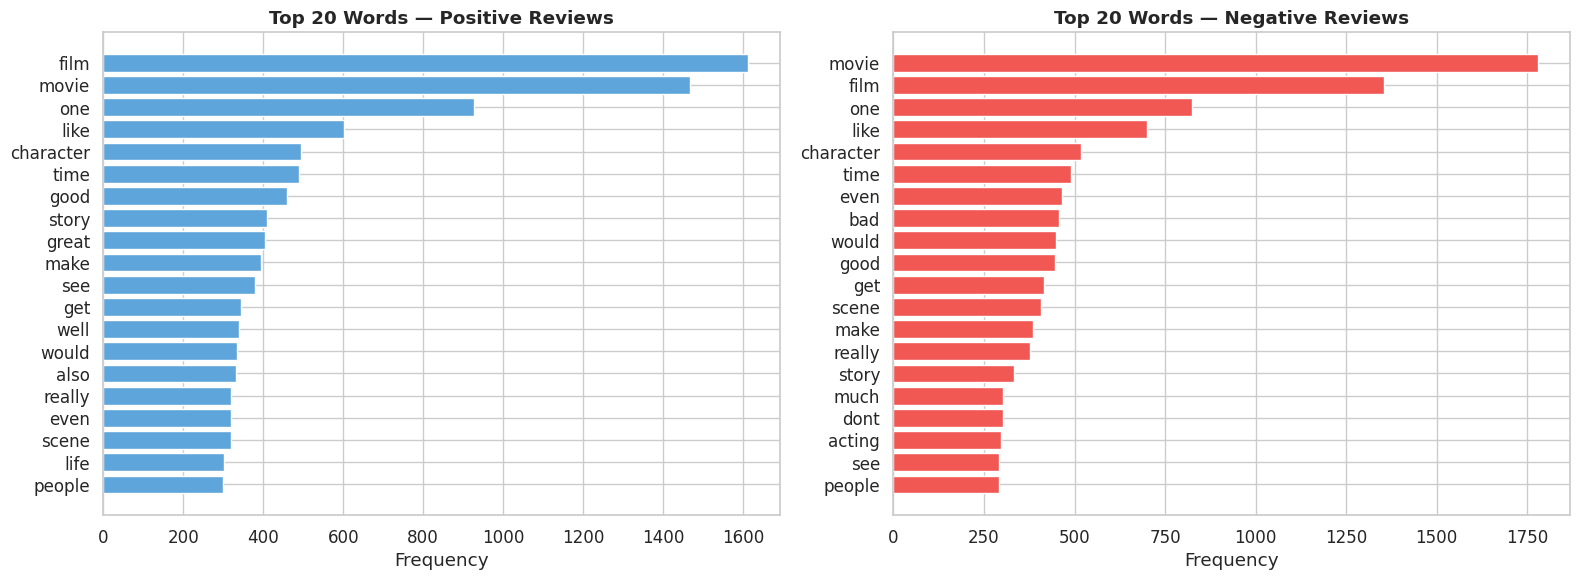

In [ ]:
def get_top_words(df, sentiment, n=20):
    all_words = ' '.join(df[df['sentiment'] == sentiment]['clean_text']).split()
    return Counter(all_words).most_common(n)


pos_words = get_top_words(train_df, 'positive')
neg_words = get_top_words(train_df, 'negative')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, words, title, color in [
    (axes[0], pos_words, 'Top 20 Words — Positive Reviews', '#5DA5DA'),
    (axes[1], neg_words, 'Top 20 Words — Negative Reviews', '#F15854'),
]:
    labels, cnts = zip(*words)
    ax.barh(labels[::-1], cnts[::-1], color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

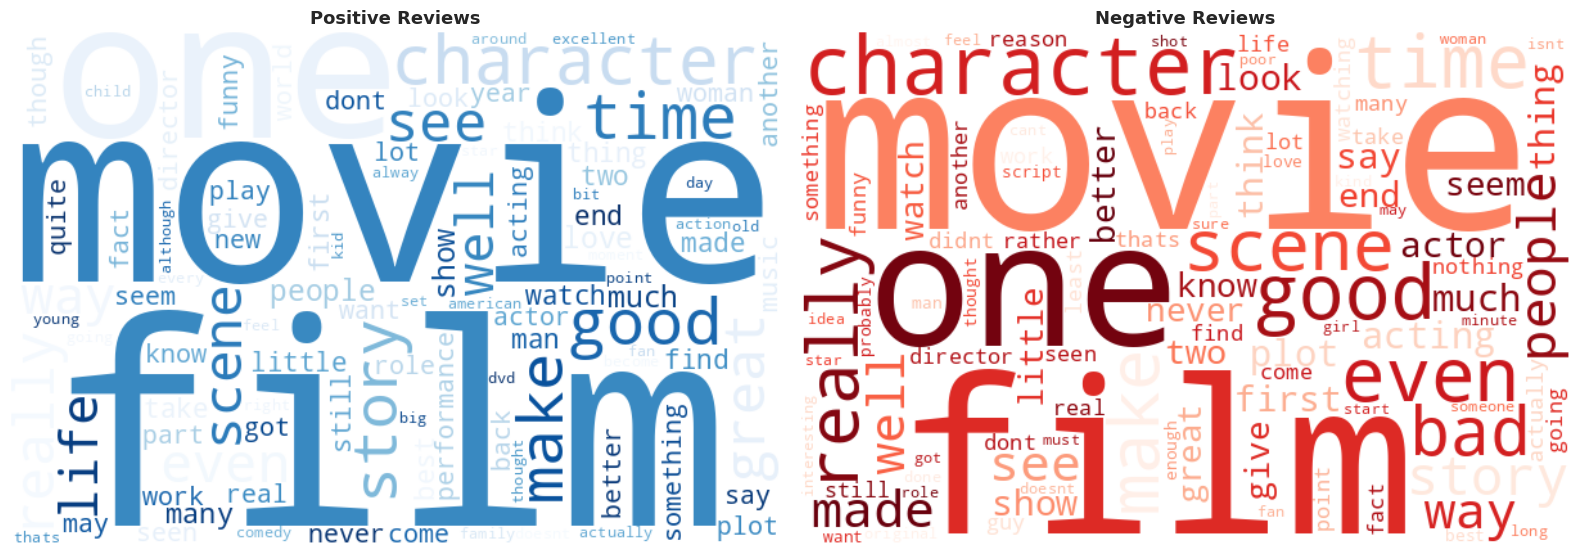

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sentiment, title in [
    (axes[0], 'positive', 'Positive Reviews'),
    (axes[1], 'negative', 'Negative Reviews'),
]:
    text_blob = ' '.join(train_df[train_df['sentiment'] == sentiment]['clean_text'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   max_words=100, colormap='Blues' if sentiment == 'positive' else 'Reds')
    wc.generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

---

## Step 5 — TF-IDF Feature Extraction

### Bag-of-Words vs TF-IDF

**Bag-of-Words (BoW):** Counts how many times each word appears. Problem: common words like "film" dominate even though they don't distinguish positive from negative.

**TF-IDF (Term Frequency – Inverse Document Frequency):**
- **TF(t, d):** How often term *t* appears in document *d*
- **IDF(t):** log(N / df(t)) — penalises terms that appear in many documents
- **TF-IDF = TF × IDF** — words frequent in a document but rare overall get high scores

A word like "brilliant" in a positive review gets a high score, while "movie" (appears everywhere) gets a low score.

In [ ]:
X_train = train_df['clean_text']
y_train = train_df['label']

X_test  = test_df['clean_text']
y_test  = test_df['label']

# ngram_range=(1,2) includes unigrams and bigrams (e.g. "not good" as one feature)
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test):  {X_test_tfidf.shape}")
print(f"Sparsity: {100 * (1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])):.2f}% sparse")

TF-IDF matrix shape (train): (1600, 20000)
TF-IDF matrix shape (test):  (400, 20000)
Sparsity: 99.46% sparse


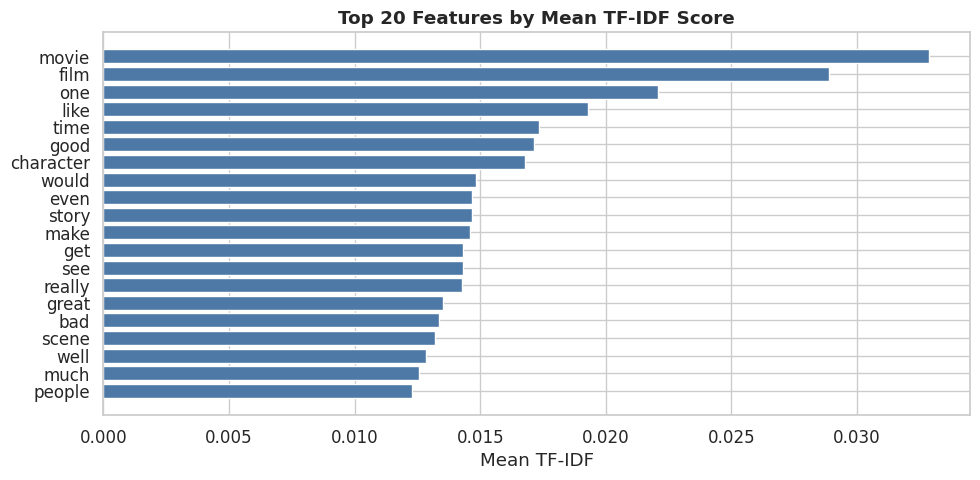

In [ ]:
feature_names = tfidf.get_feature_names_out()
mean_tfidf    = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
top_indices   = mean_tfidf.argsort()[-20:][::-1]

plt.figure(figsize=(10, 5))
plt.barh([feature_names[i] for i in top_indices[::-1]],
         [mean_tfidf[i] for i in top_indices[::-1]], color='#4E79A7')
plt.title('Top 20 Features by Mean TF-IDF Score', fontweight='bold')
plt.xlabel('Mean TF-IDF')
plt.tight_layout()
plt.show()

---

## Step 6 — Classical ML Classifiers

### Model 1 — Logistic Regression

A natural first choice for text classification. Each TF-IDF feature gets a weight indicating how much it pushes towards positive or negative sentiment.

In [ ]:
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_tfidf, y_train)

lr_preds = lr.predict(X_test_tfidf)
lr_probs = lr.predict_proba(X_test_tfidf)[:, 1]

print("Logistic Regression:")
print(f"  Accuracy : {accuracy_score(y_test, lr_preds):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, lr_probs):.4f}")
print()
print(classification_report(y_test, lr_preds, target_names=['Negative', 'Positive']))

Logistic Regression:
  Accuracy : 0.8475
  ROC-AUC  : 0.9264

              precision    recall  f1-score   support

    Negative       0.86      0.83      0.85       200
    Positive       0.84      0.86      0.85       200

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



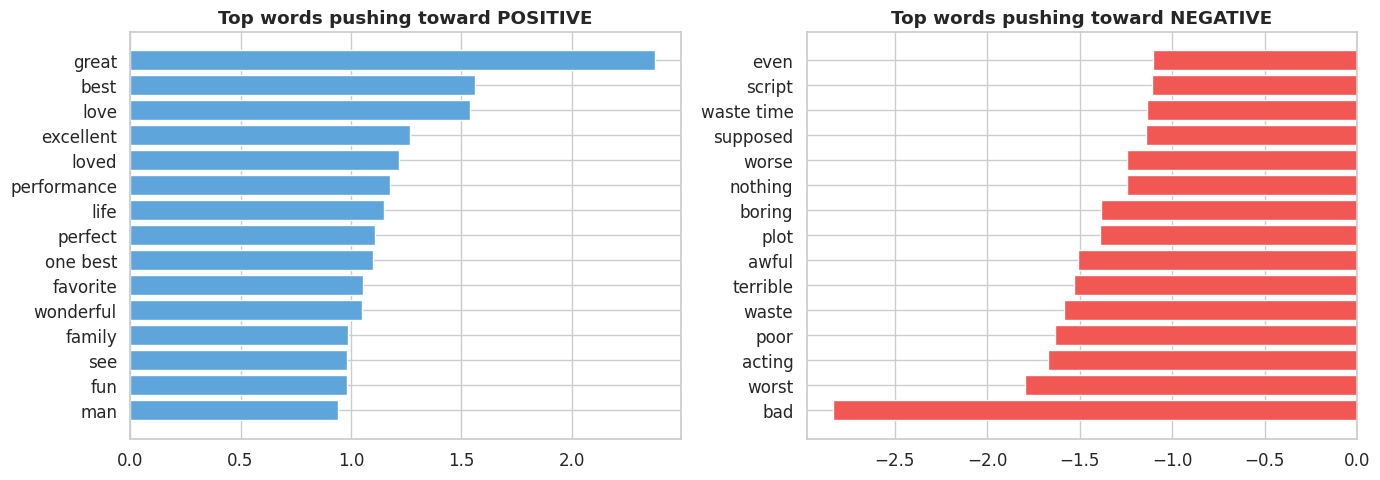

In [ ]:
# Coefficients show which words drive each class
coef = lr.coef_[0]
top_pos_idx = coef.argsort()[-15:][::-1]
top_neg_idx = coef.argsort()[:15]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh([feature_names[i] for i in top_pos_idx[::-1]],
             [coef[i] for i in top_pos_idx[::-1]], color='#5DA5DA')
axes[0].set_title('Top words pushing toward POSITIVE', fontweight='bold')

axes[1].barh([feature_names[i] for i in top_neg_idx],
             [coef[i] for i in top_neg_idx], color='#F15854')
axes[1].set_title('Top words pushing toward NEGATIVE', fontweight='bold')

plt.tight_layout()
plt.show()

### Model 2 — Multinomial Naive Bayes

Naive Bayes assumes features (words) are conditionally independent given the class. Despite being a strong assumption, it works well for text and is extremely fast.

In [ ]:
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train)

nb_preds = nb.predict(X_test_tfidf)
nb_probs = nb.predict_proba(X_test_tfidf)[:, 1]

print("Naive Bayes:")
print(f"  Accuracy : {accuracy_score(y_test, nb_preds):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, nb_probs):.4f}")
print()
print(classification_report(y_test, nb_preds, target_names=['Negative', 'Positive']))

Naive Bayes:
  Accuracy : 0.8325
  ROC-AUC  : 0.9195

              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83       200
    Positive       0.82      0.84      0.83       200

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



### Model 3 — Linear SVC

Support Vector Machine with a linear kernel finds the maximum-margin hyperplane separating the two classes in TF-IDF space. It tends to outperform Logistic Regression on high-dimensional sparse text data.

In [ ]:
svc = LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE)
svc.fit(X_train_tfidf, y_train)

svc_preds = svc.predict(X_test_tfidf)

print("Linear SVC:")
print(f"  Accuracy : {accuracy_score(y_test, svc_preds):.4f}")
print()
print(classification_report(y_test, svc_preds, target_names=['Negative', 'Positive']))

Linear SVC:
  Accuracy : 0.8500

              precision    recall  f1-score   support

    Negative       0.86      0.84      0.85       200
    Positive       0.84      0.86      0.85       200

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



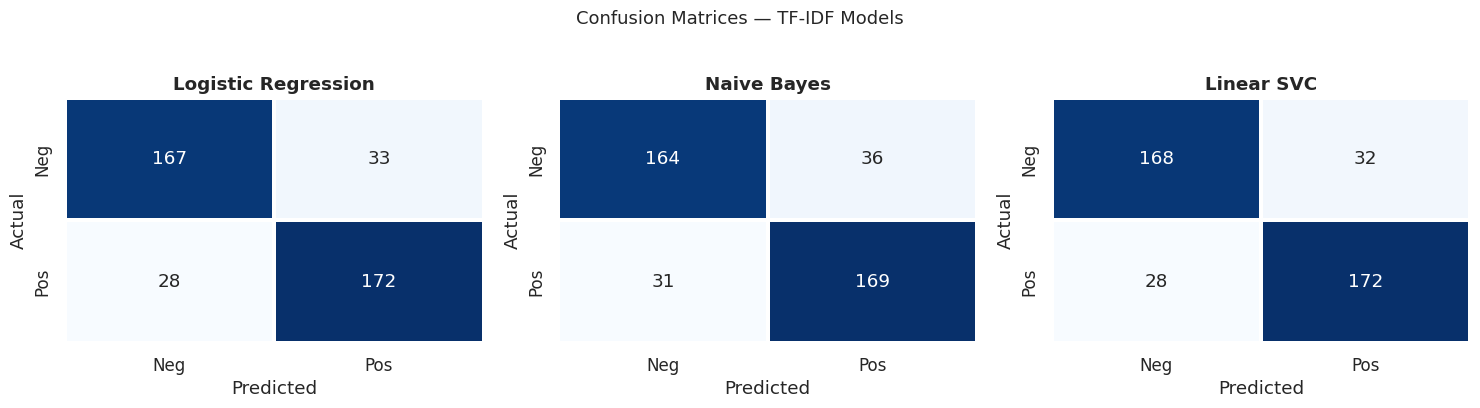

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, preds, title in [
    (axes[0], lr_preds,  'Logistic Regression'),
    (axes[1], nb_preds,  'Naive Bayes'),
    (axes[2], svc_preds, 'Linear SVC'),
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
                cbar=False, linewidths=1.5, linecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — TF-IDF Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## Step 7 — Word Embeddings

### Why Embeddings?

TF-IDF treats every word as independent. "great" and "excellent" have no relationship in TF-IDF space. Word embeddings map words into a dense vector space where semantically similar words are close together.

### Word2Vec

Word2Vec (Mikolov et al., 2013) trains a shallow neural network on one of two tasks:
- **CBOW:** Predict the centre word from context words
- **Skip-gram:** Predict context words from the centre word

Words that appear in similar contexts end up with similar vectors: `king - man + woman ≈ queen`.

In [ ]:
print("Tokenizing corpus for Word2Vec...")
w2v_corpus = [text.split() for text in train_df['clean_text']]

print(f"Corpus size: {len(w2v_corpus)} documents")
print(f"Sample tokens: {w2v_corpus[0][:10]}")

Tokenizing corpus for Word2Vec...
Corpus size: 1600 documents
Sample tokens: ['okay', 'love', 'silly', 'movie', 'enjoy', 'silly', 'scifi', 'movie', 'top', 'movie']


In [ ]:
print("Training Word2Vec...")
w2v_model = Word2Vec(
    sentences=w2v_corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,       # Skip-gram
    epochs=5,
    seed=RANDOM_STATE
)

print(f"Vocabulary size: {len(w2v_model.wv.key_to_index)}")
print(f"Vector dimensions: {w2v_model.wv.vector_size}")

Training Word2Vec...
Vocabulary size: 5082
Vector dimensions: 100


In [ ]:
print("Most similar words to 'brilliant':")
for word, score in w2v_model.wv.most_similar('brilliant', topn=6):
    print(f"  {word:<20} {score:.4f}")

print("\nMost similar words to 'terrible':")
for word, score in w2v_model.wv.most_similar('terrible', topn=6):
    print(f"  {word:<20} {score:.4f}")

print("\nAnalogy — 'good' is to 'great' as 'bad' is to:")
for word, score in w2v_model.wv.most_similar(positive=['great', 'bad'], negative=['good'], topn=3):
    print(f"  {word:<20} {score:.4f}")

Most similar words to 'brilliant':
  eastwood             0.9922
  clever               0.9922
  amusing              0.9911
  note                 0.9908
  thoroughly           0.9908
  considering          0.9902

Most similar words to 'terrible':
  awful                0.9865
  script               0.9834
  dialog               0.9757
  writing              0.9742
  horrible             0.9714
  dialogue             0.9604

Analogy — 'good' is to 'great' as 'bad' is to:
  writing              0.9000
  terrible             0.8931
  decent               0.8758


### 7.1 — t-SNE Visualization of Word Vectors

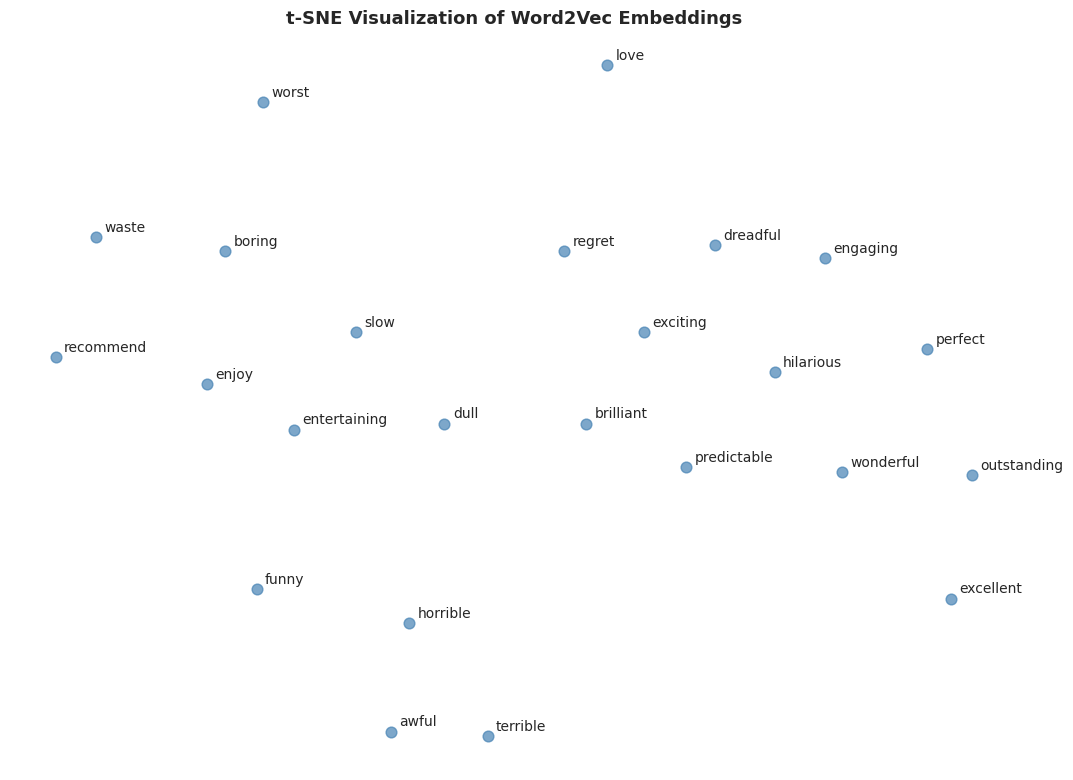

In [ ]:
sentiment_words = [
    'brilliant', 'excellent', 'outstanding', 'wonderful', 'perfect',
    'terrible', 'awful', 'horrible', 'dreadful', 'worst',
    'boring', 'dull', 'slow', 'predictable', 'waste',
    'funny', 'hilarious', 'entertaining', 'engaging', 'exciting',
    'love', 'enjoy', 'recommend', 'disappoint', 'regret'
]
sentiment_words = [w for w in sentiment_words if w in w2v_model.wv]
vectors = np.array([w2v_model.wv[w] for w in sentiment_words])

tsne   = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=min(10, len(sentiment_words) - 1))
coords = tsne.fit_transform(vectors)

plt.figure(figsize=(11, 8))
plt.scatter(coords[:, 0], coords[:, 1], color='steelblue', s=60, alpha=0.7)
for i, word in enumerate(sentiment_words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]),
                 textcoords='offset points', xytext=(6, 4), fontsize=10)
plt.title('t-SNE Visualization of Word2Vec Embeddings', fontweight='bold', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

### 7.2 — Word2Vec for Classification

Each review is represented as the mean of its word vectors, then passed to a Logistic Regression classifier.

In [ ]:
def review_to_vector(tokens, model, dim=100):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)


print("Building document vectors...")
X_train_w2v = np.array([review_to_vector(tokens, w2v_model) for tokens in w2v_corpus])

test_corpus = [text.split() for text in test_df['clean_text']]
X_test_w2v  = np.array([review_to_vector(tokens, w2v_model) for tokens in test_corpus])

print(f"Train matrix: {X_train_w2v.shape} | Test matrix: {X_test_w2v.shape}")

Building document vectors...
Train matrix: (1600, 100) | Test matrix: (400, 100)


In [ ]:
lr_w2v = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_w2v.fit(X_train_w2v, y_train)

w2v_preds = lr_w2v.predict(X_test_w2v)
w2v_probs = lr_w2v.predict_proba(X_test_w2v)[:, 1]

print("Logistic Regression + Word2Vec mean vectors:")
print(f"  Accuracy : {accuracy_score(y_test, w2v_preds):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, w2v_probs):.4f}")

Logistic Regression + Word2Vec mean vectors:
  Accuracy : 0.6950
  ROC-AUC  : 0.7774


---

## Step 8 — Transformers & BERT

### Architecture Overview

BERT (Devlin et al., 2018) is a deep transformer model pretrained on Masked Language Modelling and Next Sentence Prediction.

| Property | Word2Vec / GloVe | BERT |
|---|---|---|
| Context | Static (one vector per word) | Dynamic (context-dependent) |
| "bank" | Same vector always | Different in "river bank" vs "bank account" |
| Architecture | Shallow network | 12-layer transformer |
| Training data | ~1B words | 3.3B words |
| Fine-tuning | No | Yes — add a classification head |

We use **DistilBERT** — 40% smaller, 60% faster, retains 97% of BERT performance.

### WordPiece Tokenization

In [ ]:
from transformers import AutoTokenizer

bert_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

sample_text = "I absolutely loved this movie. The acting was superb and the story was captivating."
tokens    = bert_tokenizer.tokenize(sample_text)
token_ids = bert_tokenizer.encode(sample_text)

print("Input text:", sample_text)
print("Tokens:    ", tokens)
print("Token IDs: ", token_ids)
print("\n[CLS] = sequence start token (used for classification)")
print("[SEP] = sequence end token")
print("## prefix = subword continuation token")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Input text: I absolutely loved this movie. The acting was superb and the story was captivating.
Tokens:     ['i', 'absolutely', 'loved', 'this', 'movie', '.', 'the', 'acting', 'was', 'superb', 'and', 'the', 'story', 'was', 'capt', '##ivating', '.']
Token IDs:  [101, 1045, 7078, 3866, 2023, 3185, 1012, 1996, 3772, 2001, 21688, 1998, 1996, 2466, 2001, 14408, 17441, 1012, 102]

[CLS] = sequence start token (used for classification)
[SEP] = sequence end token
## prefix = subword continuation token


### Fine-tuning DistilBERT

We load pretrained DistilBERT, add a 2-class linear head, and fine-tune for a few epochs.

> Using 2,000 training / 500 test samples by default. Increase `N_TRAIN` / `N_TEST` if running on GPU.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if str(DEVICE) == 'cpu':
    print("CPU detected. Using small subset for speed. GPU recommended for full training.")

Device: cuda


In [ ]:
MAX_LEN    = 128
BATCH_SIZE = 16
EPOCHS     = 10

# Dataset is already small (1,600 train / 400 test) so we use it fully for BERT
bert_train = train_df.copy()
bert_test  = test_df.copy()

print(f"BERT train: {len(bert_train)} | BERT test: {len(bert_test)}")
print(f"Label balance (train): {bert_train['label'].value_counts().to_dict()}")

BERT train: 1600 | BERT test: 400
Label balance (train): {1: 800, 0: 800}


In [ ]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

train_dataset = IMDBDataset(bert_train['review'], bert_train['label'], tokenizer, MAX_LEN)
test_dataset  = IMDBDataset(bert_test['review'],  bert_test['label'],  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Train batches: 100 | Test batches: 25


In [ ]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
).to(DEVICE)

total_params     = sum(p.numel() for p in bert_model.parameters())
trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     66,955,010
Trainable parameters: 66,955,010


In [ ]:
optimizer   = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

train_losses = []

for epoch in range(EPOCHS):
    bert_model.train()
    epoch_loss, correct = 0, 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}"):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += outputs.loss.item()
        correct    += (outputs.logits.argmax(dim=1) == labels).sum().item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"  Epoch {epoch + 1} — Loss: {avg_loss:.4f} | Train Acc: {correct / len(train_dataset):.4f}")

Epoch 1/10: 100%|██████████| 100/100 [00:19<00:00,  5.01it/s]


  Epoch 1 — Loss: 0.6114 | Train Acc: 0.6663


Epoch 2/10: 100%|██████████| 100/100 [00:20<00:00,  4.90it/s]


  Epoch 2 — Loss: 0.3660 | Train Acc: 0.8438


Epoch 3/10: 100%|██████████| 100/100 [00:20<00:00,  4.87it/s]


...

  Epoch 8 — Loss: 0.0089 | Train Acc: 0.9981


Epoch 9/10: 100%|██████████| 100/100 [00:20<00:00,  4.91it/s]


  Epoch 9 — Loss: 0.0032 | Train Acc: 0.9994


Epoch 10/10: 100%|██████████| 100/100 [00:20<00:00,  4.88it/s]

  Epoch 10 — Loss: 0.0011 | Train Acc: 1.0000


In [ ]:
bert_model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1)[:, 1]
        preds   = outputs.logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

bert_acc = accuracy_score(all_labels, all_preds)
bert_auc = roc_auc_score(all_labels, all_probs)

print("DistilBERT Fine-tuned Results:")
print(f"  Accuracy : {bert_acc:.4f}")
print(f"  ROC-AUC  : {bert_auc:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

DistilBERT Fine-tuned Results:
  Accuracy : 0.8150
  ROC-AUC  : 0.9084

              precision    recall  f1-score   support

    Negative       0.83      0.80      0.81       200
    Positive       0.80      0.83      0.82       200

    accuracy                           0.81       400
   macro avg       0.82      0.81      0.81       400
weighted avg       0.82      0.81      0.81       400



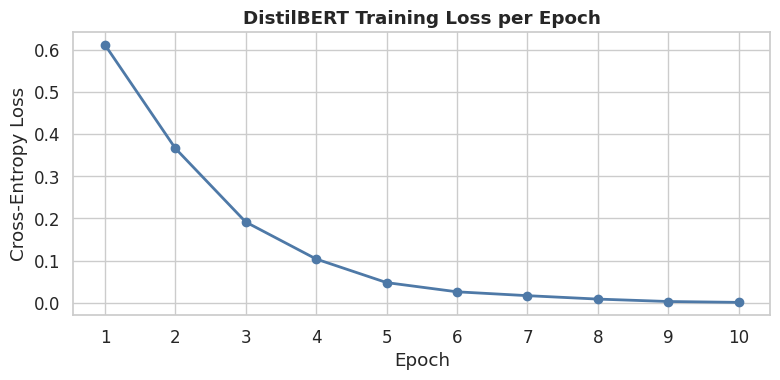

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', color='#4E79A7', linewidth=2)
plt.title('DistilBERT Training Loss per Epoch', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.xticks(range(1, EPOCHS + 1))
plt.tight_layout()
plt.show()

---

## Step 9 — Full Model Comparison

In [ ]:
# All models evaluated on the same 400-sample test set
results = [
    {'Model': 'Logistic Regression (TF-IDF)', 'Accuracy': accuracy_score(y_test, lr_preds),  'ROC-AUC': roc_auc_score(y_test, lr_probs),  'Test set': '400'},
    {'Model': 'Naive Bayes (TF-IDF)',          'Accuracy': accuracy_score(y_test, nb_preds),  'ROC-AUC': roc_auc_score(y_test, nb_probs),  'Test set': '400'},
    {'Model': 'Linear SVC (TF-IDF)',           'Accuracy': accuracy_score(y_test, svc_preds), 'ROC-AUC': 'N/A',                            'Test set': '400'},
    {'Model': 'Logistic Regression (Word2Vec)','Accuracy': accuracy_score(y_test, w2v_preds), 'ROC-AUC': roc_auc_score(y_test, w2v_probs), 'Test set': '400'},
    {'Model': 'DistilBERT (fine-tuned)',        'Accuracy': bert_acc,                          'ROC-AUC': bert_auc,                          'Test set': '400'},
]

results_df = pd.DataFrame(results).set_index('Model')
print("Model Comparison:")
print(results_df.to_string())

Model Comparison:
                                Accuracy   ROC-AUC Test set
Model                                                      
Logistic Regression (TF-IDF)      0.8475  0.926425      400
Naive Bayes (TF-IDF)              0.8325  0.919525      400
Linear SVC (TF-IDF)               0.8500       N/A      400
Logistic Regression (Word2Vec)    0.6950   0.77745      400
DistilBERT (fine-tuned)           0.8150    0.9084      400


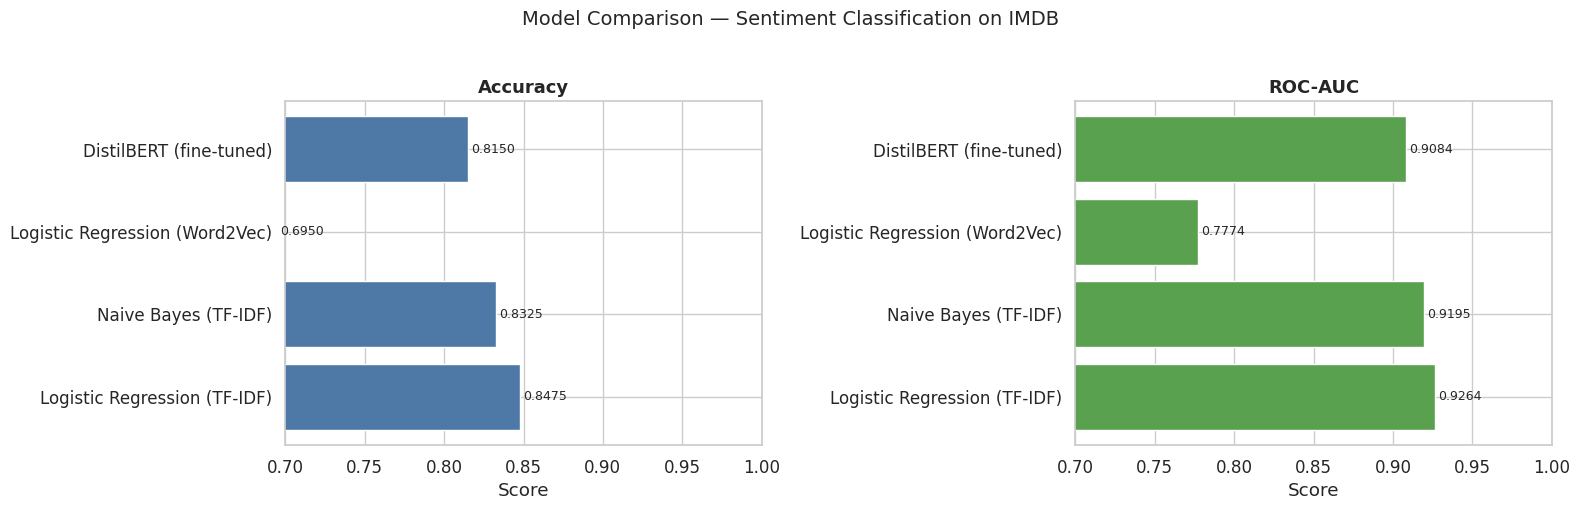

In [ ]:
numeric_results = results_df[results_df['ROC-AUC'] != 'N/A'].copy()
numeric_results['Accuracy'] = numeric_results['Accuracy'].astype(float)
numeric_results['ROC-AUC']  = numeric_results['ROC-AUC'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, color in [
    (axes[0], 'Accuracy', '#4E79A7'),
    (axes[1], 'ROC-AUC',  '#59A14F'),
]:
    ax.barh(numeric_results.index, numeric_results[metric], color=color, edgecolor='white')
    ax.set_xlim(0.7, 1.0)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_xlabel('Score')
    for i, v in enumerate(numeric_results[metric]):
        ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — Sentiment Classification on IMDB', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## Step 10 — Predict on Custom Text

In [ ]:
custom_reviews = [
    "This film was absolutely stunning. The performances were extraordinary and the cinematography was breathtaking.",
    "Complete waste of time. Terrible plot, awful dialogue, and the ending made no sense whatsoever.",
    "It was okay. Not the best movie I've seen but not the worst either. Some good moments.",
    "One of the greatest films ever made. A masterpiece of storytelling and direction.",
]

print("TF-IDF + Logistic Regression Predictions:")
print("-" * 60)
for review in custom_reviews:
    vec   = tfidf.transform([preprocess(review)])
    pred  = lr.predict(vec)[0]
    prob  = lr.predict_proba(vec)[0][1]
    label = 'POSITIVE' if pred == 1 else 'NEGATIVE'
    print(f"  {label} ({prob:.2%})  {review[:65]}...")
    print()

TF-IDF + Logistic Regression Predictions:
------------------------------------------------------------
  POSITIVE (67.45%)  This film was absolutely stunning. The performances were extraord...

  NEGATIVE (12.31%)  Complete waste of time. Terrible plot, awful dialogue, and the en...

  NEGATIVE (49.39%)  It was okay. Not the best movie I've seen but not the worst eithe...

  POSITIVE (60.14%)  One of the greatest films ever made. A masterpiece of storytellin...



In [ ]:
print("DistilBERT Predictions:")
print("-" * 60)
bert_model.eval()

for review in custom_reviews:
    enc = tokenizer(
        review, max_length=MAX_LEN, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    with torch.no_grad():
        output = bert_model(
            input_ids=enc['input_ids'].to(DEVICE),
            attention_mask=enc['attention_mask'].to(DEVICE)
        )
    prob  = torch.softmax(output.logits, dim=1)[0][1].item()
    label = 'POSITIVE' if prob >= 0.5 else 'NEGATIVE'
    print(f"  {label} ({prob:.2%})  {review[:65]}...")
    print()

DistilBERT Predictions:
------------------------------------------------------------
  POSITIVE (99.92%)  This film was absolutely stunning. The performances were extraord...

  NEGATIVE (0.08%)  Complete waste of time. Terrible plot, awful dialogue, and the en...

  POSITIVE (99.79%)  It was okay. Not the best movie I've seen but not the worst eithe...

  POSITIVE (99.90%)  One of the greatest films ever made. A masterpiece of storytellin...



---

## Summary

### Key Takeaways

| Concept | What was learned |
|---|---|
| **Text preprocessing** | HTML removal, lowercasing, stopword removal, stemming vs lemmatization |
| **TF-IDF** | Sparse representation; penalises common words; bigrams capture phrases like "not good" |
| **Logistic Regression** | Strong baseline; interpretable via coefficients |
| **Naive Bayes** | Very fast; competitive but assumes feature independence |
| **Linear SVC** | Often best classical model for text classification |
| **Word2Vec** | Dense embeddings capture semantics; mean-pooling loses word order |
| **BERT/DistilBERT** | Context-aware; handles negation and sarcasm; needs GPU for full training |

### When to Use Which Approach

- **TF-IDF + LinearSVC** — fast, interpretable, works well with limited data
- **Word2Vec + LR** — when dense representations and semantic similarity matter
- **BERT fine-tuning** — when accuracy is the priority and GPU is available
- **Prompt engineering / LLM API** — zero-shot classification when labelled data is scarce
